# Sensitivity Analysis for Energy Calibration

This notebook walks through **`sisepuede/calibration/sensitivity.py`** step by step. All the real logic lives in that module; here we just call it to see each piece in action.

**What is tested here:**
1. Setup — imports, paths, baseline model run
2. Single-variable manual test (`perturb_inputs` standalone)
3. OAT — single variable
4. OAT — multiple variables
5. LHS — single variable
6. LHS — multiple variables
7. Sensitivity scores (Spearman rank correlation)
8. Linearity check (scatter + residual plot)

**Order of use for the actual analysis:**
1. Run OAT to quickly screen which variables matter.
2. Run LHS on the sensitive subset. The result of this can double as surrogate training data.
3. Use `linearity_check` to decide whether linear calibration or an optimiser is needed, or some other approach.

> **Simplex-group note:** Fuel-fraction variables (e.g. `frac_inen_energy_cement_coal`) belong to simplex groups that must sum to 1 within each industry category. Free scalar scaling breaks this constraint. For now we vary them freely as a first-pass screen. 
Simplex-aware perturbation should be added in the future; use the `is_simplex_group` flag on `VariableSpec` to annotate which variables need it.

---
## 1. Setup

In [28]:
import warnings
warnings.filterwarnings("ignore")

import sys
# Add the repo root so local edits take precedence over the installed package
path = "/Users/dianamendez/sisepuede"
if path not in sys.path:
    sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk        import IEACrosswalk
from sisepuede.calibration.iea_data_loader      import IEADataLoader
from sisepuede.calibration.sensitivity          import (
    VariableSpec,
    perturb_inputs,
    sample_oat,
    sample_lhs,
    SensitivityRunner,
    sensitivity_scores,
    linearity_check,
)

# ── Paths — change these ─────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/Documents/sisepuede/sisepuede_raw_inputs_latest_LBY_modified_march_2026.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"
PATH_CROSSWALK_FILE  = "/Users/dianamendez/sisepuede/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
ISO_COUNTRY          = "LBY"
TRUE_DATA_LIMIT_YEAR = 2023   # rows beyond this year are projections, not actuals
TARGET_YEARS         = [2015] # calendar year(s) used when scoring/plotting
# ─────────────────────────────────────────────────────────────────────────────

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes
print("model_attributes loaded")

model_attributes loaded


---
### Load inputs and build models

`EnergyConsumption` depends on outputs from `AFOLU` and `IPPU`, so we construct all three and keep the merged upstream output for merging.

In [2]:
from sisepuede.models.afolu              import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu               import IPPU
from sisepuede.manager.sisepuede_models  import SISEPUEDEModels

# ── Build sector models ───────────────────────────────────────────────────────
model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

# ── Load input CSV ────────────────────────────────────────────────────────────
df_input_raw = pd.read_csv(PATH_SISEPUEDE_INPUT)

# Keep only rows up to the last year of actual observed data
df_input = df_input_raw.loc[df_input_raw["year"] <= TRUE_DATA_LIMIT_YEAR].copy()
df_input = df_input.reset_index(drop=True)

print(f"Input shape: {df_input.shape}  |  years: {df_input['year'].min()}–{df_input['year'].max()}")

Input shape: (9, 2420)  |  years: 2015–2023


In [3]:
# Run upstream models (AFOLU + IPPU) so EnergyConsumption has their outputs
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

# Merge upstream outputs into the input frame that EnergyConsumption will see
df_input_energy = df_input.merge(df_out_afolu, on="time_period", how="left", suffixes=("", "_afolu"))
df_input_energy = df_input_energy.merge(df_out_ippu,  on="time_period", how="left", suffixes=("", "_ippu"))

print(f"Merged input shape: {df_input_energy.shape}")
display(df_input_energy.head())

Merged input shape: (9, 3075)


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,prod_ippu_textiles_tonne,prod_ippu_wood_tonne,qty_ippu_recycled_glass_used_in_production_tonne,qty_ippu_recycled_metals_used_in_production_tonne,qty_ippu_recycled_paper_used_in_production_tonne,qty_ippu_recycled_plastic_used_in_production_tonne,qty_ippu_recycled_rubber_and_leather_used_in_production_tonne,qty_ippu_recycled_textiles_used_in_production_tonne,qty_ippu_recycled_wood_used_in_production_tonne,emission_co2e_subsector_total_ippu
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,48447.635882,18333.230000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,7.774851
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,48300.041099,18277.378170,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.117254
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,48608.700362,18394.178942,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.055875
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,48859.433286,18489.059617,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10.146697
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,...,48353.411914,18297.574397,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.179068


### Load IEA data and build the crosswalk

In [4]:
loader     = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)
df_iea_raw = loader.load_country(ISO_COUNTRY)

xw = IEACrosswalk(model_attributes, path_crosswalk=PATH_CROSSWALK_FILE)
print(f"Crosswalk: {len(xw.df_crosswalk)} mappable (balance, product) pairs")

Crosswalk: 64 mappable (balance, product) pairs


### Build the `SensitivityRunner`

The runner needs a **single** input DataFrame for one country that already
contains the upstream outputs (AFOLU + IPPU) merged in — exactly what
`df_input_energy` is.  The baseline model run is **lazy**: it only happens
on the first call to `run_oat()` or `run_lhs()`, and is cached for all
subsequent perturbation runs.

> ! `SensitivityRunner` currently wraps `EnergyConsumption` directly.
> If we want full integrated runs (all sectors), pass a `SISEPUEDEModels` instance instead and set `include_energy_production` accordingly.

In [5]:
runner = SensitivityRunner(
    models                    = model_energycon,  # or a SISEPUEDEModels instance
    df_baseline               = df_input_energy,
    iea_crosswalk             = xw,
    df_iea_raw                = df_iea_raw,
    iso                       = ISO_COUNTRY,
    include_energy_production = False,
)
print("SensitivityRunner ready")

SensitivityRunner ready


---
## 2. Single-variable manual test — `perturb_inputs` standalone

`perturb_inputs` is a pure function: no runner, no model needed.
We can use it directly in a notebook cell to quickly inspect what a specific parameter change looks like in the input DataFrame before committing to a full sensitivity run.

In [6]:
# ── Choose the variable we want to test ──────────────────────────────────────
VAR = "frac_inen_energy_cement_coal"   # <- change this to any column in df_input_energy
SCALE = 0.8                            # <- 0.8 = reduce by 20 %

# Verify the column exists before running the model
assert VAR in df_input_energy.columns, f"Column not found: {VAR}"

# Apply the perturbation
df_perturbed = perturb_inputs(df_input_energy, {VAR: SCALE})

# Inspect the change
comparison = pd.DataFrame({
    "baseline":   df_input_energy[VAR].values,
    "perturbed":  df_perturbed[VAR].values,
    "scale": SCALE,
}, index=df_input_energy["year"])
comparison

,baseline,perturbed,scale
year,,,
2015,0.208886,0.167109,0.8
2016,0.195624,0.156499,0.8
2017,0.193533,0.154827,0.8
2018,0.209049,0.167239,0.8
2019,0.197802,0.158242,0.8
2020,0.166683,0.133347,0.8
2021,0.166683,0.133347,0.8
2022,0.166683,0.133347,0.8
2023,0.166683,0.133347,0.8


In [16]:
# Run the model on the perturbed input and compare IEA targets
df_out_perturbed = model_energycon(df_perturbed)
df_out_perturbed = df_out_perturbed.merge(
    df_input_energy[["time_period", "year"]].drop_duplicates(),
    on="time_period", how="left",
)

df_out_baseline = runner.baseline_output   # triggers the cached baseline run

# Build comparison tables
df_ssp_base = xw.aggregate_sisepuede(df_out_baseline)
df_ssp_pert = xw.aggregate_sisepuede(df_out_perturbed)

df_comp_base = xw.build_comparison(df_ssp_base, df_iea_raw)
df_comp_pert = xw.build_comparison(df_ssp_pert, df_iea_raw)

# Side-by-side summary for TARGET_YEARS
year_mask_b = df_comp_base["year"].isin(TARGET_YEARS)
year_mask_p = df_comp_pert["year"].isin(TARGET_YEARS)

summary = pd.DataFrame({
    "rel_err_baseline":  df_comp_base.loc[year_mask_b, "rel_err_iea"].values,
    "rel_err_perturbed": df_comp_pert.loc[year_mask_p, "rel_err_iea"].values,
}, index=(
    df_comp_base.loc[year_mask_b, "iea_balance_code"].values
    + "_"
    + df_comp_base.loc[year_mask_b, "iea_product_code"].values
))
summary["delta"] = summary["rel_err_perturbed"] - summary["rel_err_baseline"]
summary.sort_values("delta", key=abs, ascending=False).head(15)

,rel_err_baseline,rel_err_perturbed,delta
INDUSTRY_OIL,-2.042064,-2.045244,-3.179422e-03
INDUSTRY_NATGAS,-0.901238,-0.903010,-1.771312e-03
INDUSTRY_ELECTR,-1.972471,-1.974017,-1.545540e-03
INDUSTRY_INDUSTRY,-2.814955,-2.814955,-4.440892e-16
AGRICULT_AGRICULT,1.000000,1.000000,0.000000e+00
COMMPUB_COMMPUB,0.192448,0.192448,0.000000e+00
COMMPUB_ELECTR,-6.876627,-6.876627,0.000000e+00
RESIDENT_BIOWASTE,0.307600,0.307600,0.000000e+00
RESIDENT_ELECTR,-1.521761,-1.521761,0.000000e+00
RESIDENT_OIL,0.649548,0.649548,0.000000e+00


---
## 3. OAT — single variable

One-at-a-time with a single `VariableSpec`.  The runner automatically
includes an unperturbed baseline run (run 0) and then tests each level
in `levels` — 4 levels × 1 variable = **5 total runs** (including baseline).

In [29]:
specs_single = [
    VariableSpec(
        column = "frac_inen_energy_cement_coal",
        lb     = 0.5,    # lower bound for scale factor
        ub     = 1.5,    # upper bound for scale factor
        # is_simplex_group = True,   # <- uncomment once simplex perturbation is implemented
        # simplex_group_id = 1,
    ),
    VariableSpec(
        column = "frac_enfu_fuel_demand_imported_pj_fuel_diesel",
        lb     = 0.5,    # lower bound for scale factor
        ub     = 1.5,    # upper bound for scale factor
        # is_simplex_group = True,   # <- uncomment once simplex perturbation is implemented
        # simplex_group_id = 1,
    ),    
]

# Preview the sample table that will be run (no model calls yet)
sample_oat(specs_single, levels=[0.6, 0.8, 1.2, 1.4])

,frac_inen_energy_cement_coal,frac_enfu_fuel_demand_imported_pj_fuel_diesel
0,1.0,1.0
1,0.6,1.0
2,0.8,1.0
3,1.2,1.0
4,1.4,1.0
5,1.0,0.6
6,1.0,0.8
7,1.0,1.2
8,1.0,1.4


In [30]:
result_oat_single = runner.run_oat(
    specs  = specs_single,
    levels = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5],
)

print(f"\nSampling mode : {result_oat_single.sampling_mode}")
print(f"Runs completed: {len(result_oat_single.input_samples)}")
print(f"IEA comparison rows: {len(result_oat_single.iea_comparison)}")

OAT: 2 variables x 6 levels = 12 perturbations + 1 baseline (13 total runs)
  Run  1/13  baseline ... done (0.1s)
  Run  2/13  frac_inen_energy_cement_coal = 0.500 ... done (0.1s)
  Run  3/13  frac_inen_energy_cement_coal = 0.600 ... done (0.1s)
  Run  4/13  frac_inen_energy_cement_coal = 0.800 ... done (0.1s)
  Run  5/13  frac_inen_energy_cement_coal = 1.200 ... done (0.1s)
  Run  6/13  frac_inen_energy_cement_coal = 1.400 ... done (0.1s)
  Run  7/13  frac_inen_energy_cement_coal = 1.500 ... done (0.1s)
  Run  8/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.500 ... done (0.1s)
  Run  9/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.600 ... done (0.1s)
  Run 10/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.800 ... done (0.1s)
  Run 11/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.200 ... done (0.1s)
  Run 12/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.400 ... done (0.1s)
  Run 13/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.500 ... done

---
## 4. OAT — multiple variables

The exact same call, just with more `VariableSpec` entries.
N_runs = 1 (baseline) + N_vars × N_levels.

In [31]:
# A representative set spanning demand level, fuel mix, and a different sector
specs_multi = [
    # # Industrial energy — demand level
    # VariableSpec("consumpinit_inen_energy_cement",  lb=0.8, ub=1.2),
    # VariableSpec("consumpinit_inen_energy_metals",  lb=0.8, ub=1.2),

    # Industrial energy — fuel mix (simplex-constrained; free scaling for now)
    VariableSpec("frac_inen_energy_cement_coal",    lb=0.5, ub=1.5, is_simplex_group=True, simplex_group_id=1),
    VariableSpec("frac_inen_energy_cement_diesel",  lb=0.5, ub=1.5, is_simplex_group=True, simplex_group_id=1),
    VariableSpec("frac_inen_energy_cement_electricity", lb=0.5, ub=1.5, is_simplex_group=True, simplex_group_id=1),

    # # Transport demand
    # VariableSpec("demscalar_trns_road_light_duty",  lb=0.8, ub=1.2),
]

# Check all columns exist before running
missing = [s.column for s in specs_multi if s.column not in df_input_energy.columns]
if missing:
    print(f"WARNING — columns not found (update specs): {missing}")
else:
    print(f"All {len(specs_multi)} columns found in input DataFrame")

All 3 columns found in input DataFrame


In [32]:
result_oat_multi = runner.run_oat(
    specs  = specs_multi,
    levels = [0.8, 0.9, 1.1, 1.2],   # default — can omit this line
)

print(f"\nRuns completed: {len(result_oat_multi.input_samples)}")

OAT: 3 variables x 4 levels = 12 perturbations + 1 baseline (13 total runs)
  Run  1/13  baseline ... done (0.1s)
  Run  2/13  frac_inen_energy_cement_coal = 0.800 ... done (0.1s)
  Run  3/13  frac_inen_energy_cement_coal = 0.900 ... done (0.1s)
  Run  4/13  frac_inen_energy_cement_coal = 1.100 ... done (0.1s)
  Run  5/13  frac_inen_energy_cement_coal = 1.200 ... done (0.1s)
  Run  6/13  frac_inen_energy_cement_diesel = 0.800 ... done (0.1s)
  Run  7/13  frac_inen_energy_cement_diesel = 0.900 ... done (0.1s)
  Run  8/13  frac_inen_energy_cement_diesel = 1.100 ... done (0.1s)
  Run  9/13  frac_inen_energy_cement_diesel = 1.200 ... done (0.1s)
  Run 10/13  frac_inen_energy_cement_electricity = 0.800 ... done (0.1s)
  Run 11/13  frac_inen_energy_cement_electricity = 0.900 ... done (0.1s)
  Run 12/13  frac_inen_energy_cement_electricity = 1.100 ... done (0.1s)
  Run 13/13  frac_inen_energy_cement_electricity = 1.200 ... done (0.1s)

Runs completed: 13


### Inspect the raw results

`result.iea_comparison` is the key output: one row per
(run_index, balance_code, product_code, year).  Combine it with
`result.input_samples` (indexed by run_index) to link parameter values
to model responses.

In [36]:
# Input samples — each row is one model run
print("input_samples:")
display(result_oat_multi.input_samples.head(15))

# IEA comparison — stacked across all runs and all years
print(f"\niea_comparison shape: {result_oat_multi.iea_comparison.shape}")
display(result_oat_multi.iea_comparison.head(15))

input_samples:


,frac_inen_energy_cement_coal,frac_inen_energy_cement_diesel,frac_inen_energy_cement_electricity
0,1.0,1.0,1.0
1,0.8,1.0,1.0
2,0.9,1.0,1.0
3,1.1,1.0,1.0
4,1.2,1.0,1.0
5,1.0,0.8,1.0
6,1.0,0.9,1.0
7,1.0,1.1,1.0
8,1.0,1.2,1.0
9,1.0,1.0,0.8



iea_comparison shape: (9971, 18)


,run_index,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio_sisepuede_over_iea,diff_sisepuede_iea,rel_err_sisepuede,rel_err_iea
0,0,2000,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3999.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
1,0,2001,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3923.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
2,0,2002,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,3844.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
3,0,2003,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5050.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
4,0,2004,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,5076.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
5,0,2005,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,10619.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
6,0,2006,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,9230.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
7,0,2007,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,9723.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
8,0,2008,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,8031.0,total_final_energy_consumption,NaN,NaN,NaN,NaN
9,0,2009,NaN,AGRICULT,NaN,AGRICULT,NaN,NaN,NaN,NaN,NaN,LBY,7433.0,total_final_energy_consumption,NaN,NaN,NaN,NaN


In [37]:
# Full model output delta vs baseline — useful for spotting side-effects
# on outputs that are NOT in the IEA crosswalk
run_1 = result_oat_multi.model_outputs[result_oat_multi.model_outputs["run_index"] == 1]
base  = result_oat_multi.baseline_output

numeric_cols = base.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("time_period", "run_index")]

delta = (
    run_1[numeric_cols].values - base[numeric_cols].values
) / (base[numeric_cols].abs().values + 1e-10)

delta_df = pd.DataFrame(delta, columns=numeric_cols)
# Top 10 output columns most changed by run 1
delta_df.abs().mean().sort_values(ascending=False).head(10)

energy_consumption_electricity_inen_cement                 0.053446
emission_co2e_co2_inen_bmass_cement                        0.053446
emission_co2e_ch4_inen_cement                              0.044443
emission_co2e_co2_inen_nbmass_cement                       0.030465
energy_demand_inen_cement                                  0.014300
emission_co2e_n2o_inen_cement                              0.008354
totalvalue_enfu_fuel_consumed_inen_fuel_coal               0.002687
energy_demand_enfu_subsector_total_pj_inen_fuel_coal       0.002687
totalvalue_enfu_fuel_consumed_inen_fuel_biomass            0.001399
energy_demand_enfu_subsector_total_pj_inen_fuel_biomass    0.001399
dtype: float64

---
## 5. LHS — single variable

LHS with one variable is equivalent to a stratified uniform sweep — the
50 samples are evenly spread across `[lb, ub]`.  Useful as a linearity check
with smooth x-axis coverage.

In [40]:
specs_lhs_single = [
    VariableSpec("frac_scoe_heat_energy_commercial_municipal_electricity", lb=0.7, ub=1.3),
]

# Preview LHS samples (no model runs)
lhs_preview = sample_lhs(specs_lhs_single, n_samples=10, seed=42)
print("LHS sample preview (10 samples):")
display(lhs_preview)

# Check coverage of [lb, ub]
print(f"\nmin: {lhs_preview.iloc[:,0].min():.3f}  max: {lhs_preview.iloc[:,0].max():.3f}")

LHS sample preview (10 samples):


,frac_scoe_heat_energy_commercial_municipal_electricity
0,1.133563
1,0.733667
2,0.948484
3,0.838158
4,0.934349
5,1.001463
6,0.774332
7,1.192836
8,1.112313
9,1.272977



min: 0.734  max: 1.273


In [41]:
result_lhs_single = runner.run_lhs(
    specs     = specs_lhs_single,
    n_samples = 20,    # keep small for the single-variable case
    seed      = 42,
)

print(f"\nRuns completed: {len(result_lhs_single.input_samples)}")

LHS: 20 samples across 1 variables (seed=42)
  Run  1/20  1 vars perturbed ... done (0.1s)
  Run  2/20  1 vars perturbed ... done (0.1s)
  Run  3/20  1 vars perturbed ... done (0.1s)
  Run  4/20  1 vars perturbed ... done (0.1s)
  Run  5/20  1 vars perturbed ... done (0.1s)
  Run  6/20  1 vars perturbed ... done (0.1s)
  Run  7/20  1 vars perturbed ... done (0.1s)
  Run  8/20  1 vars perturbed ... done (0.1s)
  Run  9/20  1 vars perturbed ... done (0.1s)
  Run 10/20  1 vars perturbed ... done (0.1s)
  Run 11/20  1 vars perturbed ... done (0.1s)
  Run 12/20  1 vars perturbed ... done (0.1s)
  Run 13/20  1 vars perturbed ... done (0.1s)
  Run 14/20  1 vars perturbed ... done (0.1s)
  Run 15/20  1 vars perturbed ... done (0.1s)
  Run 16/20  1 vars perturbed ... done (0.1s)
  Run 17/20  1 vars perturbed ... done (0.1s)
  Run 18/20  1 vars perturbed ... done (0.1s)
  Run 19/20  1 vars perturbed ... done (0.1s)
  Run 20/20  1 vars perturbed ... done (0.1s)

Runs completed: 20


---
## 6. LHS — multiple variables

This is the **main mode for surrogate training**.  All variables are perturbed
simultaneously; each run is one point in the joint parameter space.

`result_lhs_multi.input_samples` -> X matrix (N_runs x N_vars)  
`result_lhs_multi.iea_comparison` -> pivot on year to get Y matrix (N_runs x N_iea_pairs)

In [ ]:
# Re-use the same specs_multi defined in section 4
# n_samples=50 as starting point; increase to 100-200 for surrogate training
result_lhs_multi = runner.run_lhs(
    specs     = specs_multi,
    n_samples = 50,
    seed      = 42,
)

print(f"\nRuns completed : {len(result_lhs_multi.input_samples)}")
print(f"model_outputs shape : {result_lhs_multi.model_outputs.shape}")
print(f"iea_comparison shape: {result_lhs_multi.iea_comparison.shape}")

LHS: 50 samples across 3 variables (seed=42)
  Run  1/50  3 vars perturbed ... done (0.1s)
  Run  2/50  3 vars perturbed ... done (0.1s)
  Run  3/50  3 vars perturbed ... done (0.1s)
  Run  4/50  3 vars perturbed ... done (0.1s)
  Run  5/50  3 vars perturbed ... done (0.1s)
  Run  6/50  3 vars perturbed ... done (0.1s)
  Run  7/50  3 vars perturbed ... done (0.1s)
  Run  8/50  3 vars perturbed ... done (0.1s)
  Run  9/50  3 vars perturbed ... done (0.1s)
  Run 10/50  3 vars perturbed ... done (0.1s)
  Run 11/50  3 vars perturbed ... done (0.1s)
  Run 12/50  3 vars perturbed ... done (0.1s)
  Run 13/50  3 vars perturbed ... done (0.1s)
  Run 14/50  3 vars perturbed ... done (0.1s)
  Run 15/50  3 vars perturbed ... done (0.1s)
  Run 16/50  3 vars perturbed ... done (0.1s)
  Run 17/50  3 vars perturbed ... done (0.1s)
  Run 18/50  3 vars perturbed ... done (0.1s)
  Run 19/50  3 vars perturbed ... done (0.1s)
  Run 20/50  3 vars perturbed ... done (0.1s)
  Run 21/50  3 vars perturbed ... d

In [43]:
# ── Surrogate training data ───────────────────────────────────────────────────
# X: scale factors used in each run
X_train = result_lhs_multi.input_samples
print(f"X_train shape: {X_train.shape}")
display(X_train.head(3))

# Y: IEA ratio for a specific year, pivoted to (run x IEA pair)
Y_train = (
    result_lhs_multi.iea_comparison
    [result_lhs_multi.iea_comparison["year"].isin(TARGET_YEARS)]
    .groupby(["run_index", "iea_balance_code", "iea_product_code"])["rel_err_iea"]
    .mean()
    .unstack(["iea_balance_code", "iea_product_code"])
)
Y_train.columns = [f"{b}_{p}" for b, p in Y_train.columns]
print(f"\nY_train shape: {Y_train.shape}")
display(Y_train.head(3))

X_train shape: (50, 3)


,frac_inen_energy_cement_coal,frac_inen_energy_cement_diesel,frac_inen_energy_cement_electricity
0,0.984521,1.231222,0.762828
1,1.166053,0.738116,0.960488
2,0.864777,0.764279,0.917438



Y_train shape: (50, 46)


,AGRICULT_AGRICULT,CHEMICAL_CHEMICAL,COMMPUB_BIOWASTE,COMMPUB_COAL,COMMPUB_COMMPUB,COMMPUB_ELECTR,COMMPUB_NATGAS,COMMPUB_OIL,ELECTOUT_NATGAS,ELECTOUT_OIL,...,RESIDENT_RESIDENTIAL,TEXTILES_TEXTILES,TFC_TOTAL,TRANSPORT_BIOWASTE,TRANSPORT_ELECTR,TRANSPORT_HYDROGEN,TRANSPORT_NATGAS,TRANSPORT_OIL,TRANSPORT_TRANSPORT,WOODPRO_WOODPRO
run_index,,,,,,,,,,,,,,,,,,,,,
0,1.0,NaN,NaN,NaN,0.192448,-6.876627,NaN,NaN,NaN,NaN,...,-0.597961,NaN,NaN,NaN,NaN,NaN,NaN,0.250976,0.207556,NaN
1,1.0,NaN,NaN,NaN,0.192448,-6.876627,NaN,NaN,NaN,NaN,...,-0.597961,NaN,NaN,NaN,NaN,NaN,NaN,0.250976,0.207556,NaN
2,1.0,NaN,NaN,NaN,0.192448,-6.876627,NaN,NaN,NaN,NaN,...,-0.597961,NaN,NaN,NaN,NaN,NaN,NaN,0.250976,0.207556,NaN


---
## 7. Sensitivity scores

`sensitivity_scores()` computes Spearman rank correlation between each
input scale factor and each IEA (balance, product) pair.

|r| close to **1** -> strong monotone influence  
|r| close to **0** -> weak or no influence  
**r > 0** -> increasing the variable increases the SSP/IEA ratio  
**r < 0** -> increasing the variable decreases the ratio  

Use the OAT result for a first screen (clean single-variable attribution).
Use the LHS result for a more robust multi-variable picture.

In [44]:
# Scores from the multi-variable LHS run
scores = sensitivity_scores(
    result = result_lhs_multi,
    years  = TARGET_YEARS,
    output_col = "rel_err_iea",
)

# Rows = input variables, columns = IEA (balance, product) pairs
print(f"Scores shape: {scores.shape}  (input vars x IEA pairs)")
display(scores)

Scores shape: (3, 46)  (input vars x IEA pairs)


,AGRICULT_AGRICULT,CHEMICAL_CHEMICAL,COMMPUB_BIOWASTE,COMMPUB_COAL,COMMPUB_COMMPUB,COMMPUB_ELECTR,COMMPUB_NATGAS,COMMPUB_OIL,ELECTOUT_NATGAS,ELECTOUT_OIL,...,RESIDENT_RESIDENTIAL,TEXTILES_TEXTILES,TFC_TOTAL,TRANSPORT_BIOWASTE,TRANSPORT_ELECTR,TRANSPORT_HYDROGEN,TRANSPORT_NATGAS,TRANSPORT_OIL,TRANSPORT_TRANSPORT,WOODPRO_WOODPRO
frac_inen_energy_cement_coal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frac_inen_energy_cement_diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frac_inen_energy_cement_electricity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


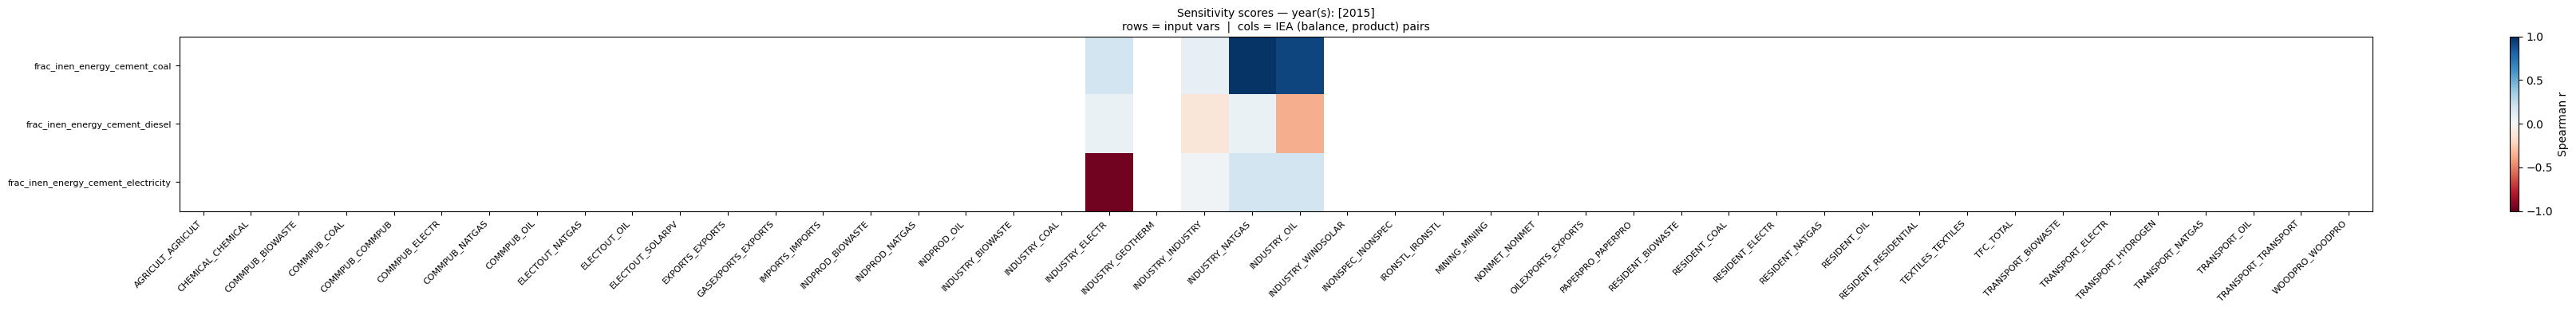

In [45]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(max(8, len(scores.columns)*0.8), max(4, len(scores)*0.6)))
im = ax.imshow(scores.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(scores.columns)))
ax.set_xticklabels(scores.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(scores.index)))
ax.set_yticklabels(scores.index, fontsize=8)

plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_title(f"Sensitivity scores — year(s): {TARGET_YEARS}\n"
             f"rows = input vars  |  cols = IEA (balance, product) pairs",
             fontsize=10)
fig.tight_layout()
plt.show()

In [46]:
# Rank input variables by their maximum absolute influence across all IEA pairs
top_vars = scores.abs().max(axis=1).sort_values(ascending=False)
print("Most influential input variables (max |Spearman r| across all IEA pairs):")
display(top_vars.to_frame(name="max_abs_r"))

Most influential input variables (max |Spearman r| across all IEA pairs):


,max_abs_r
frac_inen_energy_cement_coal,0.977719
frac_inen_energy_cement_electricity,0.963986
frac_inen_energy_cement_diesel,0.365570


---
## 8. Linearity check

`linearity_check()` produces a two-panel figure:
- **Left**: scatter of input scale factor vs IEA ratio, with a linear fit and R2.
- **Right**: residuals from that fit.

**How to interpret:**
- R2 =~ 1, random residuals -> relationship is linear -> **linear calibration is sufficient**
- Curved pattern or R2 << 1 -> nonlinear -> **use an optimiser or a surrogate model**

Run it for each variable–IEA pair combination you care about.

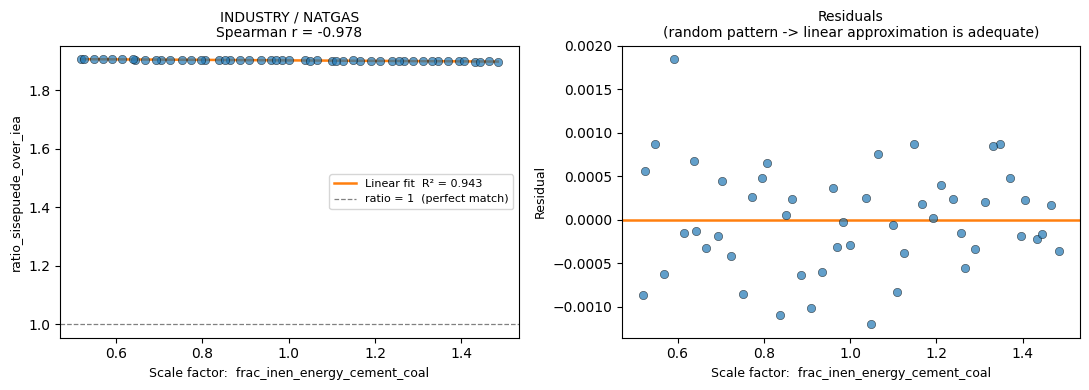

In [58]:
# Check linearity for one variable and one IEA target using the LHS result
# (smoother x-axis coverage than OAT)
fig = linearity_check(
    result           = result_lhs_multi,
    var_column       = "frac_inen_energy_cement_coal",   # x-axis
    iea_balance_code = "INDUSTRY",                          # IEA balance to check
    iea_product_code = "NATGAS",                            # IEA product to check
    years            = TARGET_YEARS,
    output_col       = "ratio_sisepuede_over_iea",
)
plt.show()

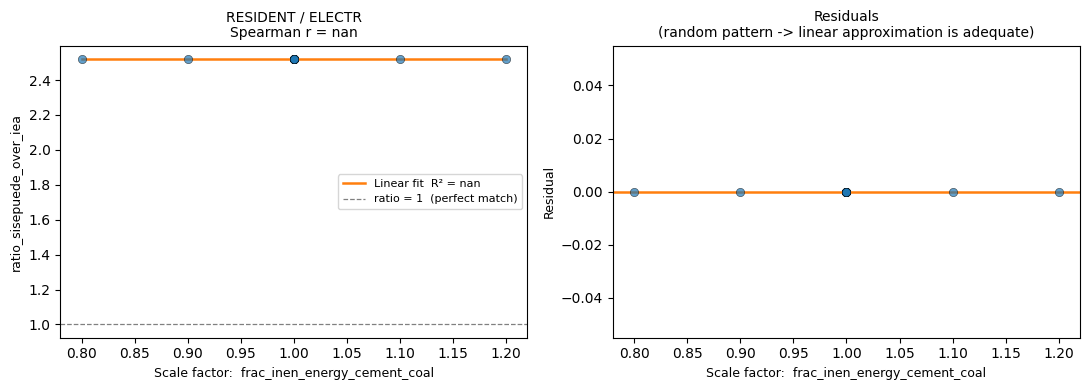

In [ ]:
# WE can also run it on an OAT result — each level becomes one point on the plot
fig = linearity_check(
    result           = result_oat_multi,
    var_column       = "frac_inen_energy_cement_coal",
    iea_balance_code = "RESIDENT",
    iea_product_code = "ELECTR",
    years            = TARGET_YEARS,
)
plt.show()

Variables with |r| > 0.3 for any IEA pair: ['frac_inen_energy_cement_coal', 'frac_inen_energy_cement_electricity', 'frac_inen_energy_cement_diesel']


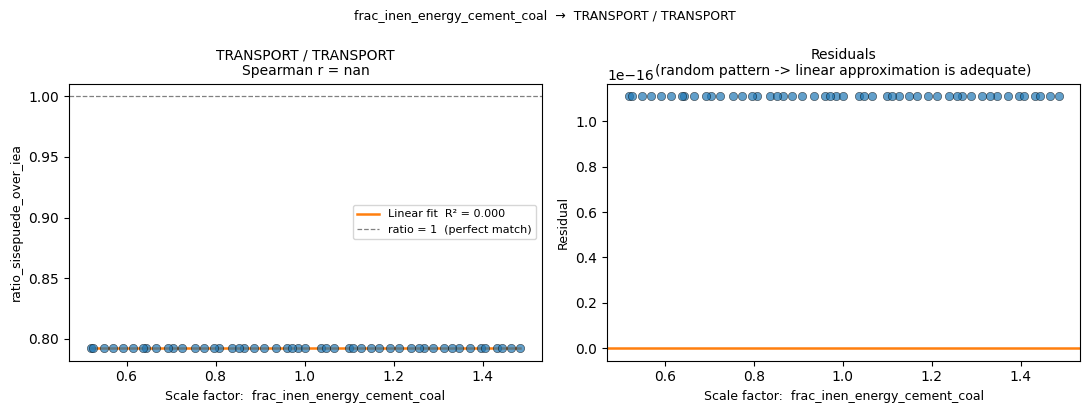

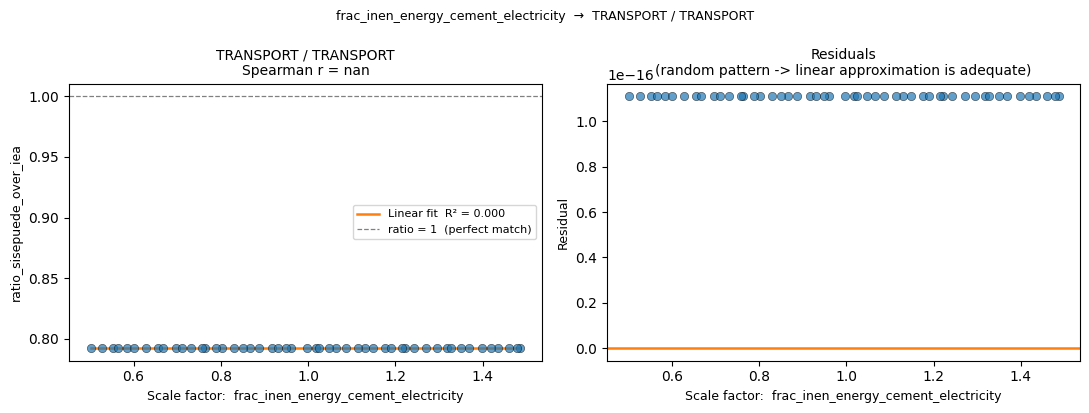

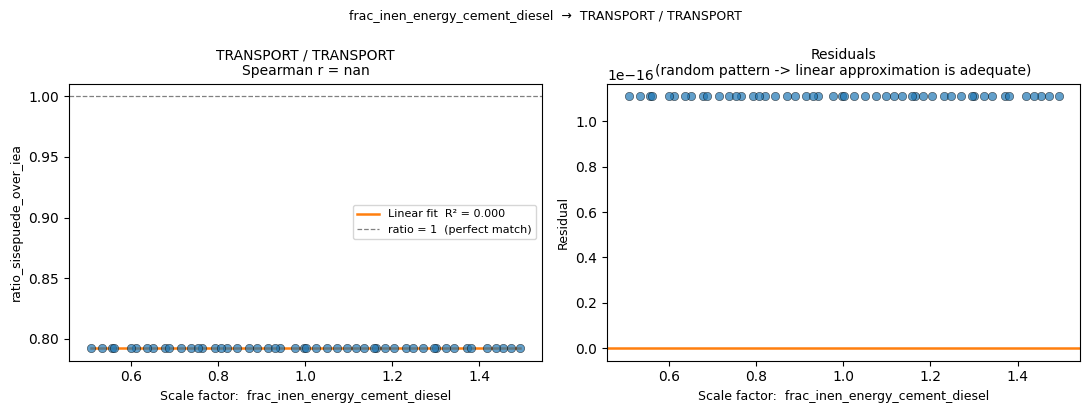

In [60]:
# Loop over all influential variables for a specific IEA pair
TARGET_BALANCE = "TRANSPORT"
TARGET_PRODUCT = "TRANSPORT"

influential = top_vars[top_vars > 0.3].index.tolist()
print(f"Variables with |r| > 0.3 for any IEA pair: {influential}")

for var in influential:
    try:
        fig = linearity_check(
            result           = result_lhs_multi,
            var_column       = var,
            iea_balance_code = TARGET_BALANCE,
            iea_product_code = TARGET_PRODUCT,
            years            = TARGET_YEARS,
        )
        fig.suptitle(f"{var}  →  {TARGET_BALANCE} / {TARGET_PRODUCT}", fontsize=9, y=1.02)
        plt.show()
    except ValueError as e:
        print(f"  skipped {var}: {e}")

---
## 9. Next steps

### If the relationship is linear
Use the sensitivity matrix to set up a **linear system** calibration:
- The Spearman scores tell you which inputs to touch and in which direction.
- `_lib.scale_inputs_single_value()` already does a one-shot linear rescaling
  for a single (input, output, target) triple.
- For multiple simultaneous targets, set up a small linear system A·Δx = Δy
  where A comes from the finite-difference sensitivities.

### If the relationship is nonlinear
Two options:

1. **Optimisation directly on the model** — use `scipy.optimize.minimize`
   (or a gradient-free method like Nelder-Mead) with a cost function built
   from `IEACrosswalk.build_comparison()`. Expensive per evaluation but exact.

2. **Surrogate model** — the LHS result is already the training data:
   `X_train` (input scale factors) and `Y_train` (IEA ratios per run).
   Fit a fast surrogate (Gaussian process, random forest, or polynomial) and
   optimise against the surrogate instead of the full model.

### Simplex-constrained variables
Fuel fractions that belong to the same simplex group (flagged with
`is_simplex_group=True` on `VariableSpec`) will eventually use a
Dirichlet-shift perturbation via `_lib.shift_fuels_based_on_single_point()`.
Until that is implemented, treat the scores for those variables as
directional indicators only — the magnitude may be understated because
the complementary fractions were not adjusted.